In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import itertools
from sklearn import tree
from sklearn.metrics import confusion_matrix

# Load local CSV file directly
recipes = pd.read_csv("recipes.csv")
print("Data loaded successfully! Shape:", recipes.shape)

Data loaded successfully! Shape: (57691, 384)


In [2]:
# 1. Safely rename the first column to 'cuisine'
recipes.rename(columns={recipes.columns[0]: "cuisine"}, inplace=True)

# 2. Convert cuisine names to lower case
recipes["cuisine"] = recipes["cuisine"].str.lower()

# 3. Standardize cuisine names
recipes.loc[recipes["cuisine"] == "austria", "cuisine"] = "austrian"
recipes.loc[recipes["cuisine"] == "belgium", "cuisine"] = "belgian"
recipes.loc[recipes["cuisine"] == "china", "cuisine"] = "chinese"
recipes.loc[recipes["cuisine"] == "canada", "cuisine"] = "canadian"
recipes.loc[recipes["cuisine"] == "netherlands", "cuisine"] = "dutch"
recipes.loc[recipes["cuisine"] == "france", "cuisine"] = "french"
recipes.loc[recipes["cuisine"] == "germany", "cuisine"] = "german"
recipes.loc[recipes["cuisine"] == "india", "cuisine"] = "indian"
recipes.loc[recipes["cuisine"] == "indonesia", "cuisine"] = "indonesian"
recipes.loc[recipes["cuisine"] == "iran", "cuisine"] = "iranian"
recipes.loc[recipes["cuisine"] == "italy", "cuisine"] = "italian"
recipes.loc[recipes["cuisine"] == "japan", "cuisine"] = "japanese"
recipes.loc[recipes["cuisine"] == "israel", "cuisine"] = "jewish"
recipes.loc[recipes["cuisine"] == "korea", "cuisine"] = "korean"
recipes.loc[recipes["cuisine"] == "lebanon", "cuisine"] = "lebanese"
recipes.loc[recipes["cuisine"] == "malaysia", "cuisine"] = "malaysian"
recipes.loc[recipes["cuisine"] == "mexico", "cuisine"] = "mexican"
recipes.loc[recipes["cuisine"] == "pakistan", "cuisine"] = "pakistani"
recipes.loc[recipes["cuisine"] == "philippines", "cuisine"] = "philippine"
recipes.loc[recipes["cuisine"] == "scandinavia", "cuisine"] = "scandinavian"
recipes.loc[recipes["cuisine"] == "spain", "cuisine"] = "spanish_portuguese"
recipes.loc[recipes["cuisine"] == "portugal", "cuisine"] = "spanish_portuguese"
recipes.loc[recipes["cuisine"] == "switzerland", "cuisine"] = "swiss"
recipes.loc[recipes["cuisine"] == "thailand", "cuisine"] = "thai"
recipes.loc[recipes["cuisine"] == "turkey", "cuisine"] = "turkish"
recipes.loc[recipes["cuisine"] == "vietnam", "cuisine"] = "vietnamese"
recipes.loc[recipes["cuisine"] == "uk-and-ireland", "cuisine"] = "uk-and-irish"
recipes.loc[recipes["cuisine"] == "irish", "cuisine"] = "uk-and-irish"

# 4. Remove cuisines with fewer than 50 recipes
recipes_counts = recipes["cuisine"].value_counts()
cuisines_to_keep = list(recipes_counts[recipes_counts > 50].index)
recipes = recipes[recipes["cuisine"].isin(cuisines_to_keep)].copy()

# 5. Convert 'Yes'/'No' ingredient markers into 1/0 numerical values
recipes.replace(to_replace="Yes", value=1, inplace=True)
recipes.replace(to_replace="No", value=0, inplace=True)

print("Preprocessing complete!")

Preprocessing complete!


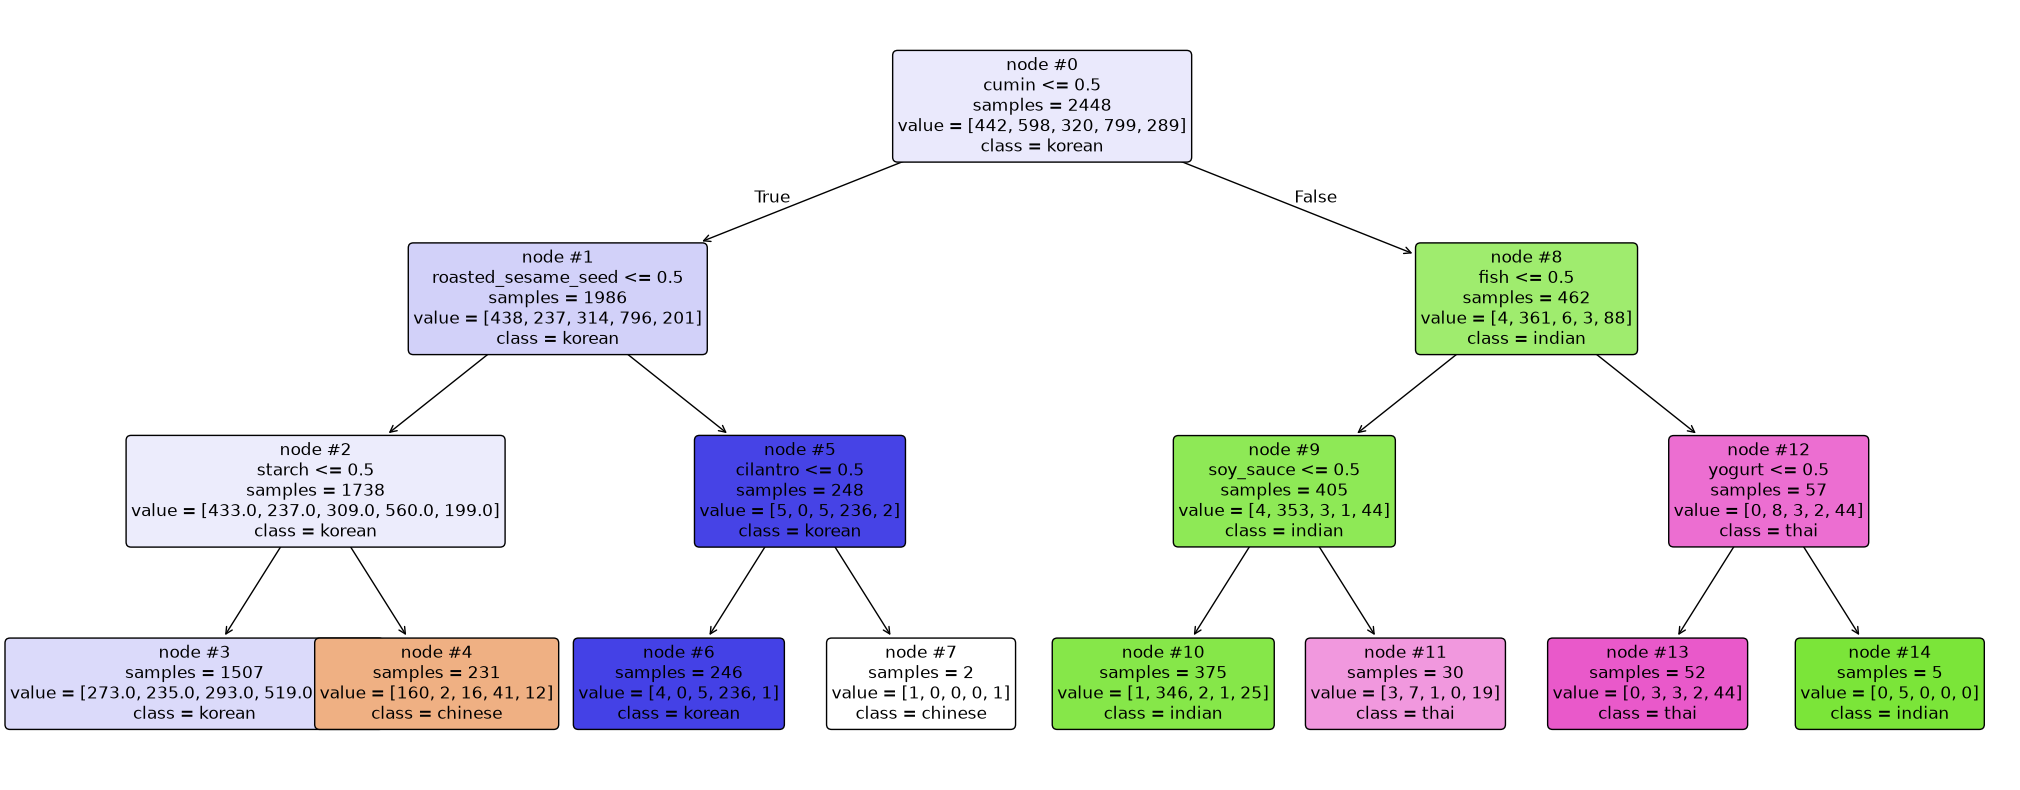

In [3]:
# Filter for Asian and Indian cuisines
asian_indian = recipes[recipes["cuisine"].isin(["korean", "japanese", "chinese", "thai", "indian"])].copy()
cuisines = asian_indian["cuisine"]
ingredients = asian_indian.iloc[:, 1:]

# Fit decision tree (depth = 3)
bamboo_tree = tree.DecisionTreeClassifier(max_depth=3, random_state=1234)
bamboo_tree.fit(ingredients, cuisines)

# Plot the tree
plt.figure(figsize=(25, 10))
tree.plot_tree(
    bamboo_tree,
    feature_names=list(ingredients.columns.values),
    class_names=np.unique(cuisines),
    filled=True,
    node_ids=True,
    impurity=False,
    rounded=True,
    fontsize=12
)
plt.show()

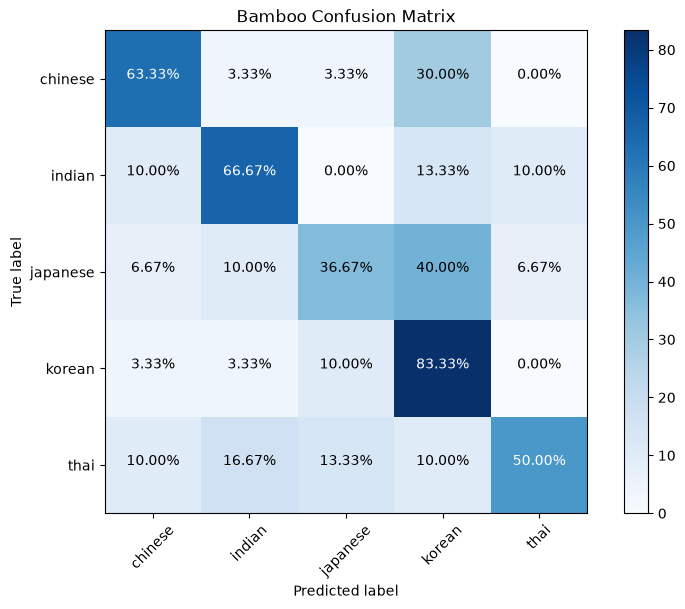

In [4]:
# 1. Filter subset dataframe
bamboo = recipes[recipes["cuisine"].isin(["korean", "japanese", "chinese", "thai", "indian"])].copy()

# 2. Sample 30 recipes per cuisine for the test set safely
sample_n = 30
bamboo_test = bamboo.groupby("cuisine").sample(n=sample_n, random_state=1234)

bamboo_test_ingredients = bamboo_test.iloc[:, 1:]
bamboo_test_cuisines = bamboo_test["cuisine"]

# 3. Create training set with the remaining recipes
bamboo_train = bamboo[~bamboo.index.isin(bamboo_test.index)].copy()
bamboo_train_ingredients = bamboo_train.iloc[:, 1:]
bamboo_train_cuisines = bamboo_train["cuisine"]

# 4. Fit deeper decision tree on training data
bamboo_train_tree = tree.DecisionTreeClassifier(max_depth=15, random_state=1234)
bamboo_train_tree.fit(bamboo_train_ingredients, bamboo_train_cuisines)

# 5. Predict test samples
bamboo_pred_cuisines = bamboo_train_tree.predict(bamboo_test_ingredients)

# 6. Compute and plot confusion matrix
test_cuisines = np.unique(bamboo_test_cuisines)
cm = confusion_matrix(bamboo_test_cuisines, bamboo_pred_cuisines, labels=test_cuisines)
cm_perc = (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]) * 100

plt.figure(figsize=(8, 6))
plt.imshow(cm_perc, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Bamboo Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(test_cuisines))
plt.xticks(tick_marks, test_cuisines, rotation=45)
plt.yticks(tick_marks, test_cuisines)

thresh = cm_perc.max() / 2.
for i, j in itertools.product(range(cm_perc.shape[0]), range(cm_perc.shape[1])):
    plt.text(j, i, f"{cm_perc[i, j]:.2f}%",
             horizontalalignment="center",
             color="white" if cm_perc[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()